# Intro to AI 03 - Search

In the lecture, we've seen
- how to model a search problem with state-space graphs
- *uninformed* search algos
- *heuristic* search algos
- the 4 important properties of heuristics: *safety*, *goal-awareness*, *consistency*, *admissibility*

In this colab, you'll get intuition how different search algorithms behave in a `Gridworld` navigation task. How do they expand nodes? What traps do they run into? How do consistency and admissibility play into the performance of heuristic algos?


In [1]:
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Grid definition: 0=Free (cost 1), 1=Wall, 2=Water (cost 5)
grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 2, 2, 2, 2, 2, 2, 2, 2, 0], # Top Route: Water (Shorter, but high cost)
    [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0], # <-- Top of the "Cup"
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0], # <-- Entrance to the Cup (Start is at 4,1)
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0], # <-- Bottom of the "Cup"
    [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  # Bottom Route: Dry (Longer, but cheap)
])
start = (4, 1)
goal = (4, 8)

def plot_grid(grid, path=[], expanded=[]):
    # Minimal plotting code to show the grid, the path taken (red line),
    # and all expanded nodes (light grey dots)
    plt.figure(figsize=(8, 5))
    plt.imshow(grid, cmap='Pastel1')
    for r, c in expanded: plt.plot(c, r, 'o', color='lightgray', markersize=8)
    if path:
        y, x = zip(*path)
        plt.plot(x, y, color='red', linewidth=3)
    plt.plot(start[1], start[0], 'go', markersize=10, label='Start')
    plt.plot(goal[1], goal[0], 'r*', markersize=15, label='Goal')
    plt.title(f"Nodes Expanded: {len(expanded)} | Path Cost: {calculate_cost(path, grid)}")
    plt.show()

def calculate_cost(path, grid):
    if not path: return 0
    return sum(5 if grid[r][c] == 2 else 1 for r, c in path[1:])

def get_neighbors(r, c):
    neighbors = []
    for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < grid.shape[0] and 0 <= nc < grid.shape[1] and grid[nr][nc] != 1:
            neighbors.append((nr, nc))
    return neighbors

Plotting the grid. Colors:
- red: free (cost 0)
- yellow: wall
- white: water (cost 5), try to avoid this

The geometry has a few features:
- trap to the right - any algo that shoots straight toward the goal will get stuck or waste time exploring in the closed room
- water on top: the shortest path by length goes over the top, but that's costly
- shortest path *by cost* takes the bottom route, even though it's longer in terms of pure steps

**Q: before implementing any algo, how well do you think the algos we've seen (BFS, DFS, UCS, Greedy, A*) will do, and what will they struggle with?**

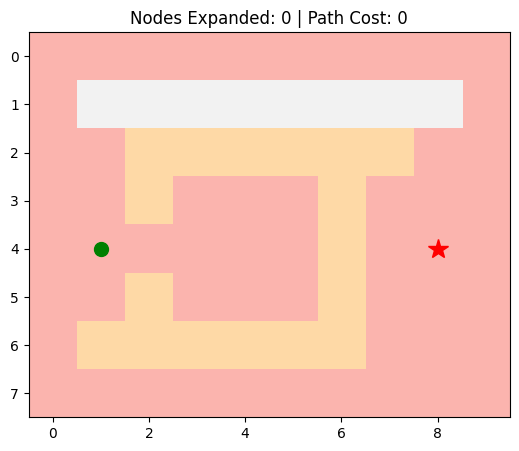

In [2]:
plot_grid(grid)

In [4]:
def generic_search(algo_type="BFS", w=1.0):
    """
    algo_type can be: 'BFS', 'DFS', 'UCS', 'Greedy', 'A*'
    """
    fringe = []
    # heapq format: (priority, counter, state, path)
    counter = 0
    heapq.heappush(fringe, (0, counter, start, [start]))

    explored = set()
    expanded_nodes = []

    while fringe:
        priority, _, current, path = heapq.heappop(fringe)

        if current in explored: continue
        explored.add(current)
        expanded_nodes.append(current)

        if current == goal:
            return path, expanded_nodes

        for nxt in get_neighbors(*current):
            if nxt not in explored:
                counter += 1

                # ---------------------------------------------------------
                # TASK 1: Define the priority for UCS, Greedy, and A*
                # Hint: path cost so far is calculate_cost(path + [nxt], grid)
                # ---------------------------------------------------------
                g_cost = calculate_cost(path + [nxt], grid)
                h_cost = heuristic(nxt, goal)

                if algo_type == "BFS":
                    priority = counter # FIFO
                elif algo_type == "DFS":
                    priority = -counter # LIFO
                elif algo_type == "UCS":
                    priority = g_cost # PATH COST
                elif algo_type == "Greedy":
                    priority = h_cost # HEURISTIC ESTIMATE
                elif algo_type == "A*":
                    priority = g_cost + (w * h_cost) # PATH COST + HEURISTIC ESTIMATE

                heapq.heappush(fringe, (priority, counter, nxt, path + [nxt]))

    return [], expanded_nodes

# ---------------------------------------------------------
# TASK 2: Implement the Manhattan Distance heuristic
# ---------------------------------------------------------
def heuristic(state, goal):
    x_diff = abs(state[0] - goal[0])
    y_diff = abs(state[1] - goal[1])
    return x_diff + y_diff

## Let's run a comparison of different search algos:

Execute both cells :)

In [5]:
def run_comparison(weight=1.0):
    algos = ['BFS', 'DFS', 'UCS', 'Greedy', 'A*']
    results = []

    # Setup subplots
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f"Search Algorithm Comparison (A* Heuristic Weight = {weight})", fontsize=16)

    for i, algo in enumerate(algos):
        path, expanded = generic_search(algo, w=weight)
        cost = calculate_cost(path, grid)

        # Save stats
        results.append({
            "Algorithm": algo,
            "Nodes Expanded": len(expanded),
            "Path Cost": cost,
            "Optimal?": "Yes" if cost == 15 else "No" # 15 is the true optimal on this map
        })

        # Plotting logic for this specific subplot
        ax = axes[i]
        ax.imshow(grid, cmap='Pastel1')
        ax.set_title(f"{algo}\nCost: {cost} | Expanded: {len(expanded)}")
        ax.axis('off')

        # Plot expanded nodes
        for r, c in expanded:
            ax.plot(c, r, 'o', color='lightgray', markersize=6)

        # Plot path
        if path:
            y, x = zip(*path)
            ax.plot(x, y, color='red', linewidth=3)

        # Plot Start/Goal
        ax.plot(start[1], start[0], 'go', markersize=8)
        ax.plot(goal[1], goal[0], 'r*', markersize=12)

    plt.tight_layout()
    plt.show()

    # Display the stats table
    df = pd.DataFrame(results)
    display(df)

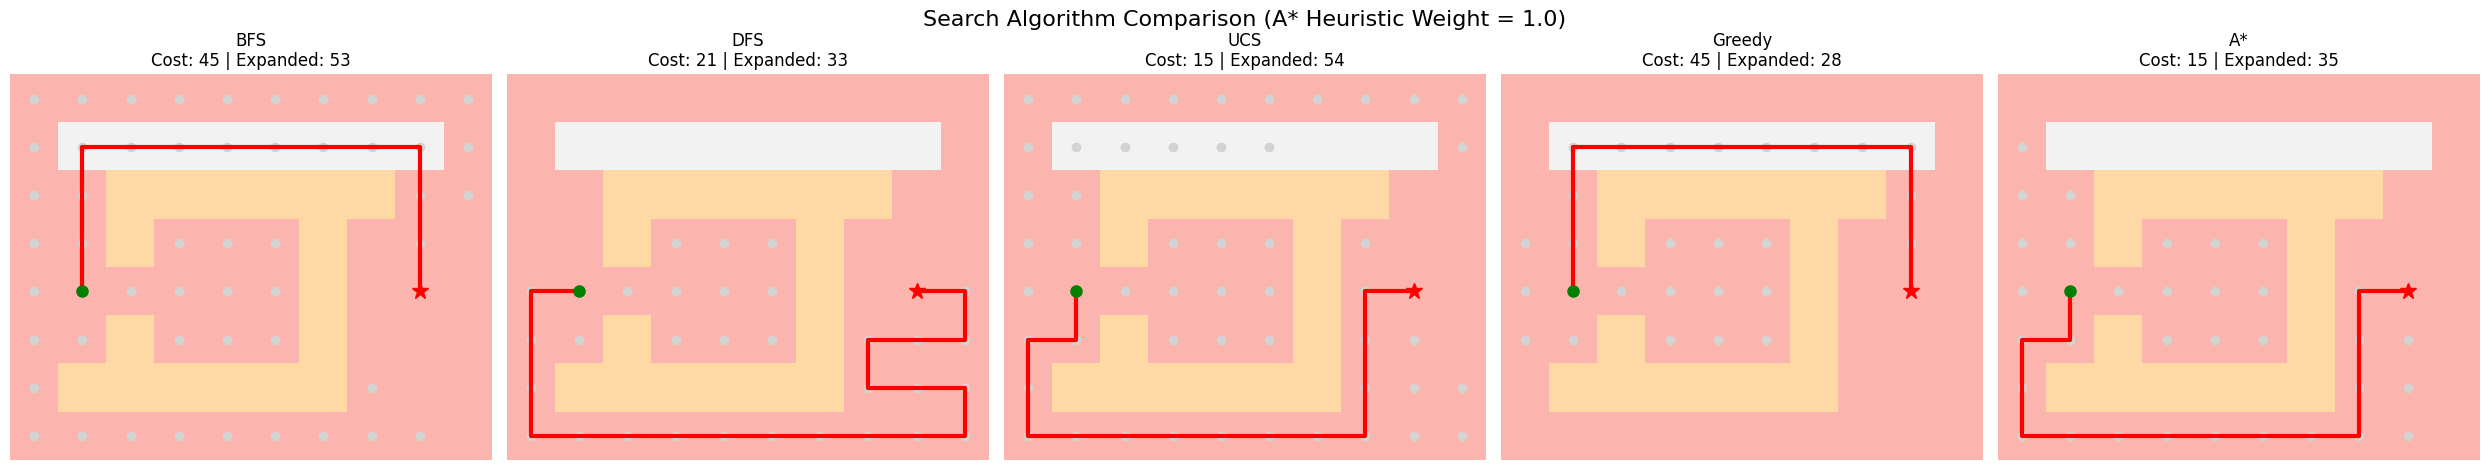

,Algorithm,Nodes Expanded,Path Cost,Optimal?
0,BFS,53,45,No
1,DFS,33,21,No
2,UCS,54,15,Yes
3,Greedy,28,45,No
4,A*,35,15,Yes


In [17]:
# Run the comparison!
# TASK: Change the weight variable.
# Try W=1 (Normal A*). Then try W=2, W=5, and W=10. What happens to A*?
run_comparison(weight=1.0)

## Weighted A-star

By changing A-star's weight, $f(n) = g(n) + w*h(n)$, we can finetune the algo.

Question: What's `w=0`, `w -> infinity`?

**High heuristic weight**: Let's say we don't have a lot of time to compute nodes. Let's put more weight on the heuristic with `weight=3.0`.

Questions
- What happens?
- What if we increase weight even further?
- What's the theory explanation for this? (hint: which property of the heuristic are we altering)

## Results/Analysis:

**BFS**: brute force, expands a LOT, ignores high water cost. 53 nodes, 45 cost

**DFS**: brute force, happens to expand into room first, due to unlucky node generation order finds non-optimal long path. 33 nodes, 21 cost

**UCS**: expands a lot like BFS, but avoids water, finds optimal route on bottom. 54 nodes, 15 cost

**Greedy**: gets stuck exploring room; picks top route through water b/c only cares about distance, not cost. 28 nodes, 45 cost

**$A^\ast$**: runs into trap because of optimistic heuristic, but backs out. tries to go top route, but when it hits water cost spikes, 35 nodes, 15 cost

-> A star has lowest cost, and nearly as few nodes as Greedy and DFS!